In [1]:
!pip install plotly
!pip install bokeh


   ---------------------------------------- 18.5/18.5 MB 752.2 kB/s eta 0:00:00


In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot

sns.set(style="whitegrid")
output_notebook()

# Load Iris dataset
df = sns.load_dataset("iris")


Loading BokehJS ...

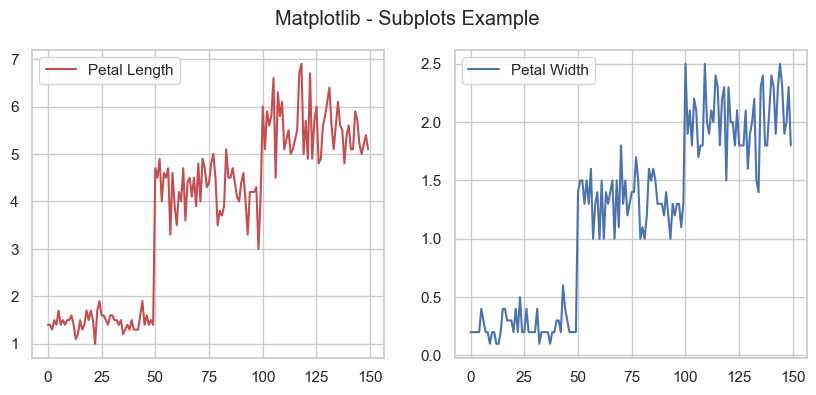

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
axs[0].plot(df['petal_length'], color='r', label="Petal Length")
axs[1].plot(df['petal_width'], color='b', label="Petal Width")
axs[0].legend(); axs[1].legend()
plt.suptitle("Matplotlib - Subplots Example")
plt.show()


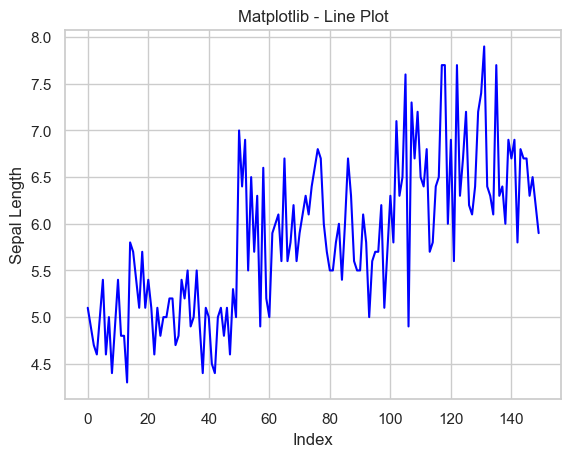

In [4]:
plt.plot(df['sepal_length'], color='blue')
plt.title("Matplotlib - Line Plot")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()


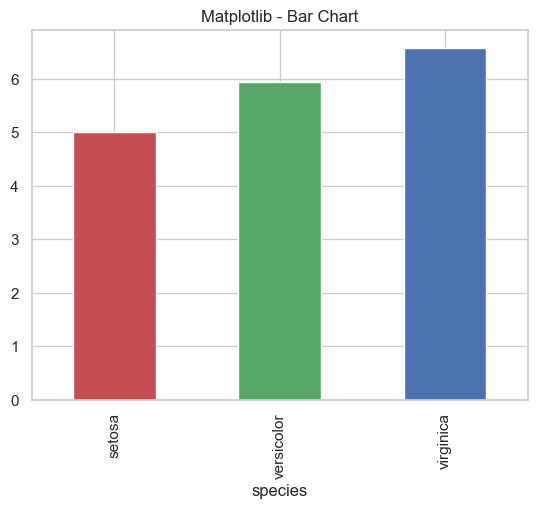

In [5]:
df.groupby('species')['sepal_length'].mean().plot(kind='bar', color=['r','g','b'])
plt.title("Matplotlib - Bar Chart")
plt.show()


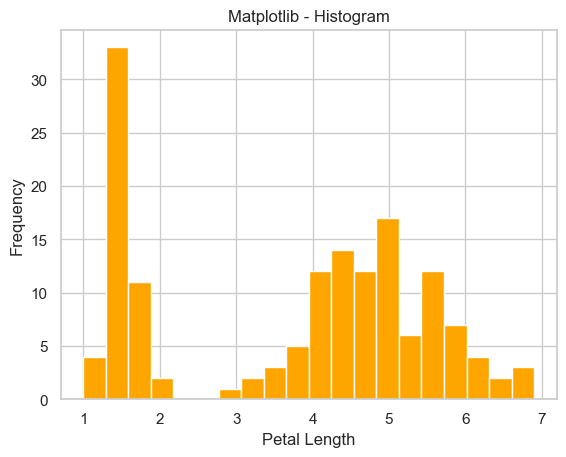

In [6]:
plt.hist(df['petal_length'], bins=20, color='orange')
plt.title("Matplotlib - Histogram")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.show()


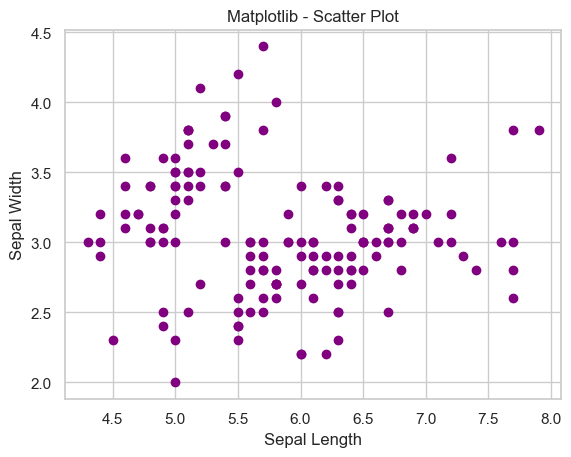

In [7]:
plt.scatter(df['sepal_length'], df['sepal_width'], c='purple')
plt.title("Matplotlib - Scatter Plot")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()


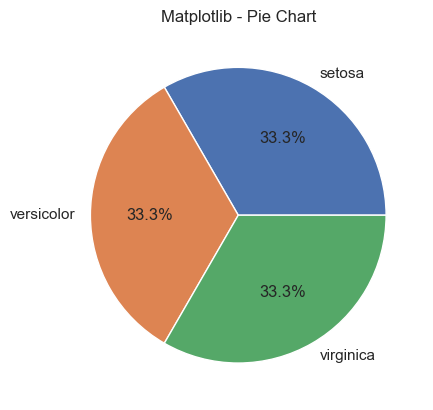

In [8]:
df['species'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Matplotlib - Pie Chart")
plt.ylabel("")
plt.show()


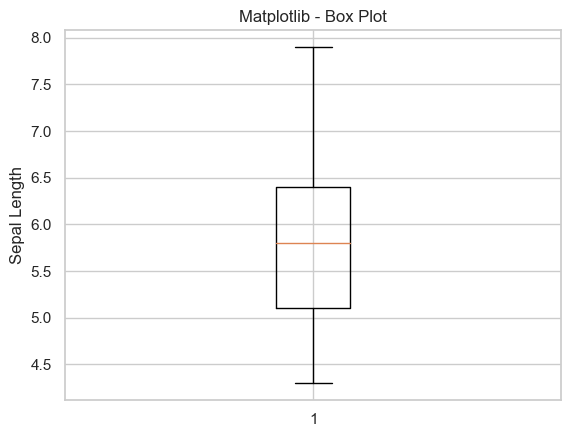

In [9]:
plt.boxplot(df['sepal_length'])
plt.title("Matplotlib - Box Plot")
plt.ylabel("Sepal Length")
plt.show()


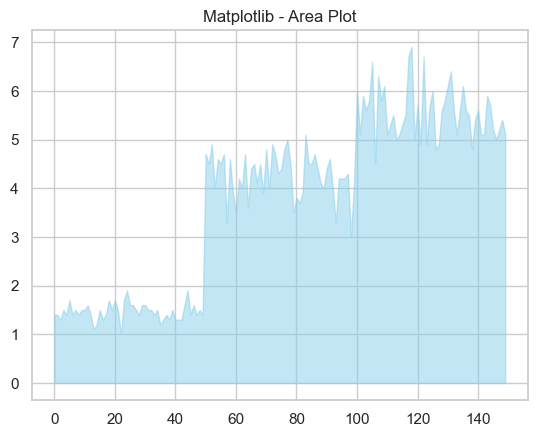

In [10]:
plt.fill_between(df.index, df['petal_length'], color='skyblue', alpha=0.5)
plt.title("Matplotlib - Area Plot")
plt.show()


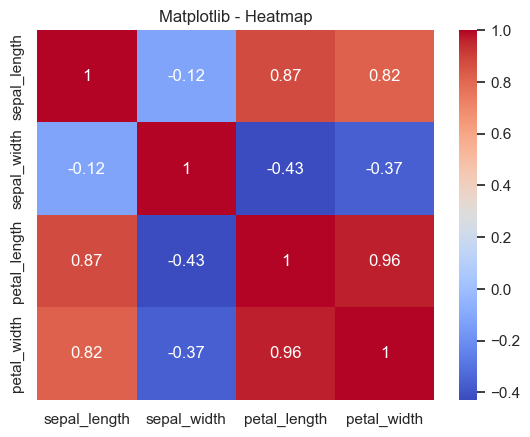

In [11]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matplotlib - Heatmap")
plt.show()


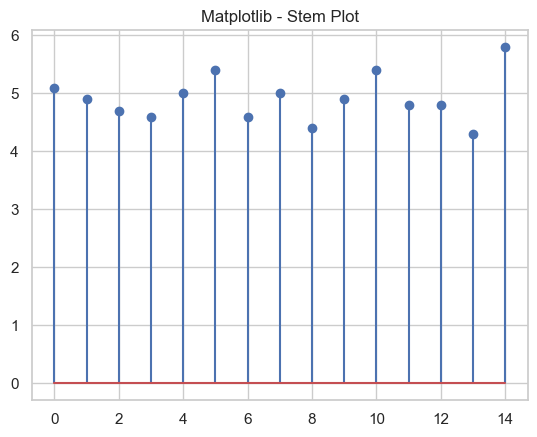

In [12]:
plt.stem(df['sepal_length'][:15])
plt.title("Matplotlib - Stem Plot")
plt.show()


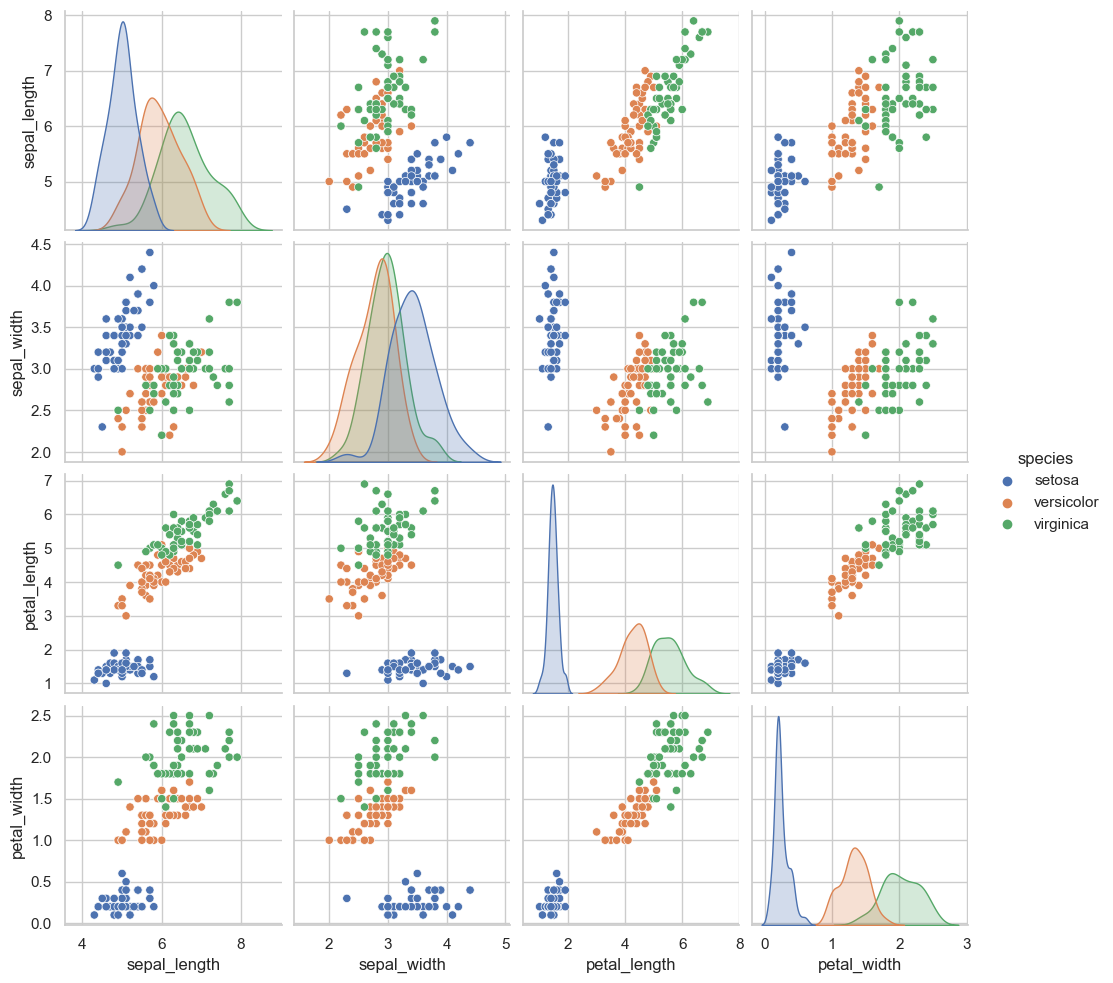

In [13]:
sns.pairplot(df, hue="species")
plt.show()


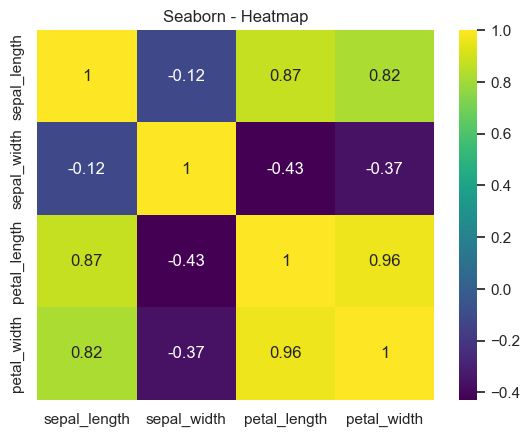

In [14]:
sns.heatmap(df.corr(), annot=True, cmap="viridis")
plt.title("Seaborn - Heatmap")
plt.show()


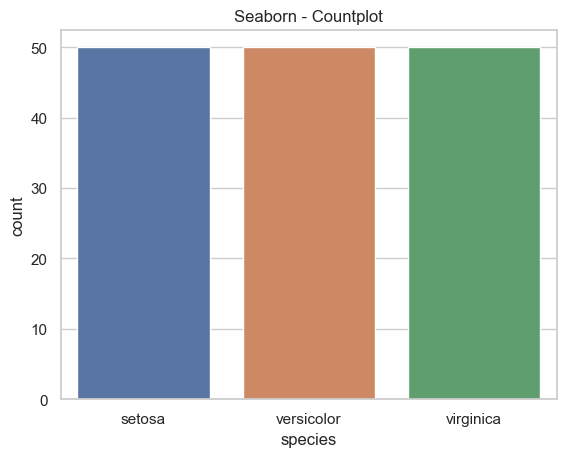

In [15]:
sns.countplot(x="species", data=df)
plt.title("Seaborn - Countplot")
plt.show()


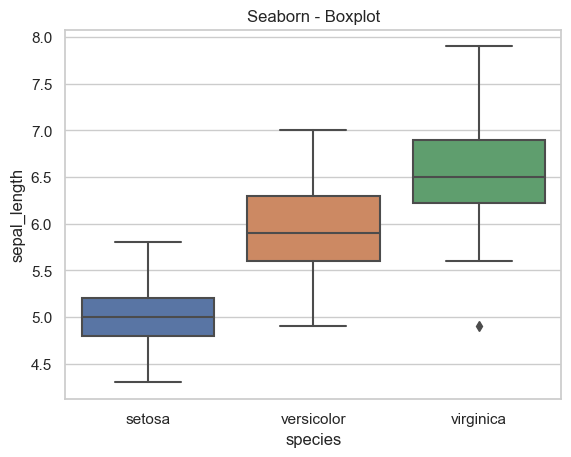

In [16]:
sns.boxplot(x="species", y="sepal_length", data=df)
plt.title("Seaborn - Boxplot")
plt.show()


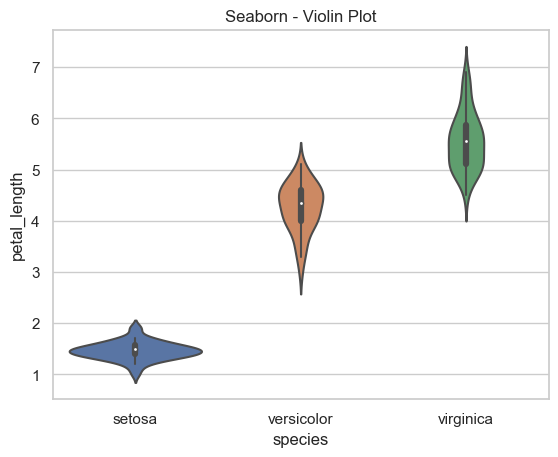

In [17]:
sns.violinplot(x="species", y="petal_length", data=df)
plt.title("Seaborn - Violin Plot")
plt.show()


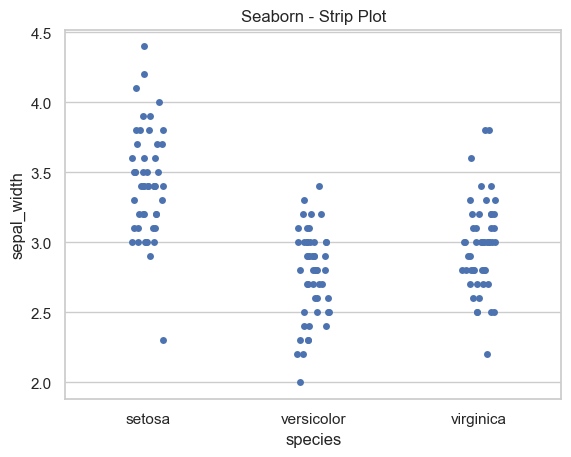

In [18]:
sns.stripplot(x="species", y="sepal_width", data=df, jitter=True)
plt.title("Seaborn - Strip Plot")
plt.show()


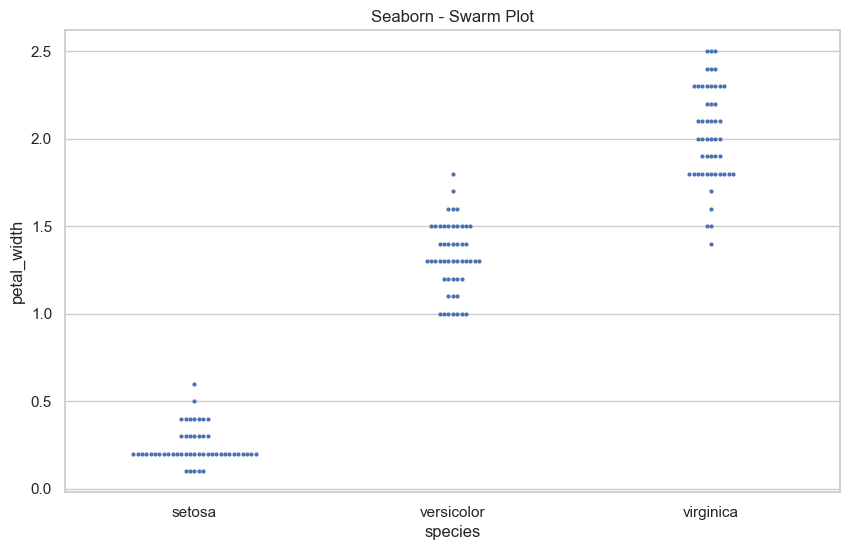

In [21]:
plt.figure(figsize=(10,6))
sns.swarmplot(
    x="species",
    y="petal_width",
    data=df,
    size=3,      # smaller markers
    dodge=True
)
plt.title("Seaborn - Swarm Plot")
plt.show()


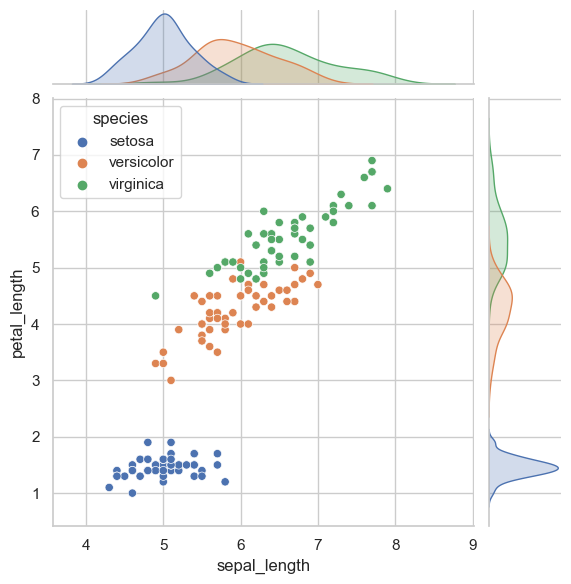

In [22]:
sns.jointplot(x="sepal_length", y="petal_length", data=df, hue="species")
plt.show()


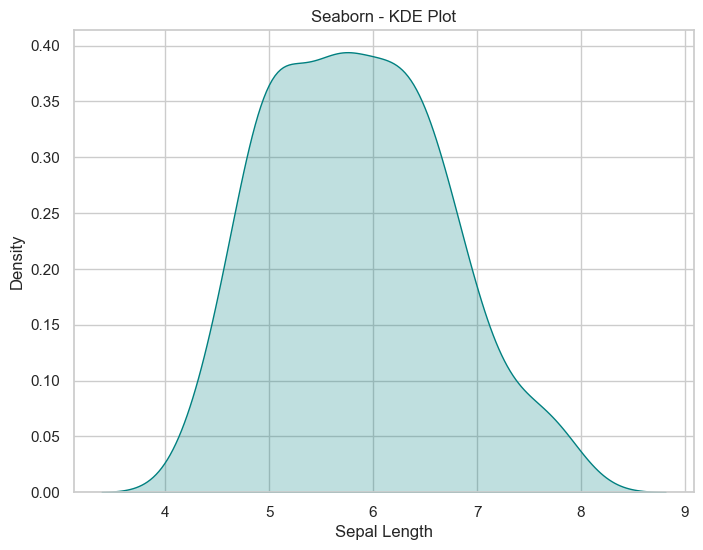

In [25]:
plt.figure(figsize=(8,6))
sns.kdeplot(df["sepal_length"], fill=True, color="teal")
plt.title("Seaborn - KDE Plot")
plt.xlabel("Sepal Length")
plt.ylabel("Density")
plt.show()

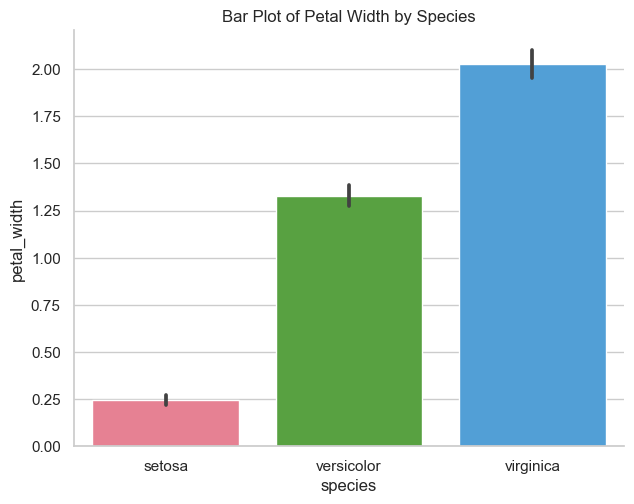

In [26]:
sns.catplot(x="species", y="petal_width", kind="bar", data=df, palette="husl", height=5, aspect=1.3)
plt.title("Bar Plot of Petal Width by Species")
plt.show()


In [32]:
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)

px.line(df, y="sepal_length", title="Plotly - Line Plot").show()


In [29]:
px.bar(df, x="species", y="sepal_length", title="Plotly - Bar Chart").show()


In [33]:
px.scatter(df, x="sepal_length", y="sepal_width", color="species", title="Plotly - Scatter Plot").show()


In [34]:
px.scatter(df, x="sepal_length", y="sepal_width", size="petal_length", color="species", title="Plotly - Bubble Plot").show()


In [35]:
px.box(df, x="species", y="petal_length", title="Plotly - Box Plot").show()


In [36]:
px.violin(df, x="species", y="sepal_width", box=True, points="all", title="Plotly - Violin Plot").show()


In [37]:
px.scatter_3d(df, x="sepal_length", y="sepal_width", z="petal_length", color="species", title="Plotly - 3D Scatter").show()


In [38]:
px.imshow(df.corr(), text_auto=True, title="Plotly - Heatmap").show()


In [39]:
px.pie(df, names="species", title="Plotly - Pie Chart").show()


In [40]:
px.sunburst(df, path=["species"], values="sepal_length", title="Plotly - Sunburst Chart").show()


In [41]:
p = figure(title="Bokeh - Line Plot")
p.line(df.index, df['sepal_length'], line_color="blue")
show(p)


In [42]:
p = figure(x_range=df['species'].unique(), title="Bokeh - Bar Chart")
means = df.groupby('species')['sepal_length'].mean()
p.vbar(x=means.index, top=means.values, width=0.5, color=["red","green","blue"])
show(p)


In [43]:
p = figure(title="Bokeh - Scatter Plot")
p.circle(df['sepal_length'], df['sepal_width'], size=8, color="purple")
show(p)


In [47]:
from bokeh.io import output_notebook
output_notebook()
means = df.groupby('species')['petal_length'].mean()

# Create figure
p = figure(title="Bokeh - Average Petal Length by Species",
           x_range=list(means.index),
           x_axis_label="Species",
           y_axis_label="Average Petal Length")

# Add vertical bars
p.vbar(x=means.index, top=means.values, width=0.5, color="skyblue")

# Show plot
show(p)




Loading BokehJS ...

In [48]:
hist, edges = np.histogram(df['sepal_length'], bins=15)
p = figure(title="Bokeh - Histogram")
p.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:], fill_color="orange", line_color="white")
show(p)


In [53]:
corr = df.corr().values
p = figure(title="Bokeh - Heatmap", x_range=list(df.columns[:4]), y_range=list(df.columns[:4]))
p.image(image=[corr], x=0, y=0, dw=4, dh=4, palette="Spectral11")
show(p)


In [54]:
p = figure(title="Bokeh - Circle Plot")
p.circle(x=df['petal_length'], y=df['petal_width'], size=10, color="green", alpha=0.6)
show(p)


In [55]:
p1 = figure(title="Plot 1"); p1.line(df.index, df['sepal_length'])
p2 = figure(title="Plot 2"); p2.circle(df.index, df['sepal_width'])
grid = gridplot([[p1, p2]])
show(grid)


In [56]:
from math import pi
from bokeh.transform import cumsum
species_counts = df['species'].value_counts().reset_index(name='value').rename(columns={'index':'species'})
species_counts['angle'] = species_counts['value']/species_counts['value'].sum() * 2*pi
species_counts['color'] = ["red","green","blue"]
p = figure(title="Bokeh - Pie Chart", toolbar_location=None)
p.wedge(x=0, y=1, radius=0.4, 
        start_angle=cumsum('angle', include_zero=True), 
        end_angle=cumsum('angle'),
        fill_color='color', legend_field='species', source=species_counts)
show(p)


In [57]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
import seaborn as sns

# Enable notebook output
output_notebook()

# Load dataset
df = sns.load_dataset("iris")

# Create figure
p_area = figure(title="Bokeh - Area Plot of Sepal Length",
                x_axis_label="Index",
                y_axis_label="Sepal Length",
                plot_width=700, plot_height=400)

# Draw the area
p_area.varea(x=df.index, y1=df['sepal_length'], y2=0, color="skyblue", alpha=0.5)

# Optionally, add a line on top
p_area.line(x=df.index, y=df['sepal_length'], line_color="blue", line_width=2)

# Show the plot
show(p_area)


Loading BokehJS ...